# Production-Ready MarketStructureEngine & SupplyDemandEngine Validation
### Forex_DNN Trading Framework - Version 1.0

This notebook serves as the comprehensive production validator and ground truth inspector for the upgraded **MarketStructureEngine** and **SupplyDemandEngine**.

### Goals
1. **Deterministic Verification**: Verify 100% time-deterministic SMC calculations across various asset classes.
2. **Multi-Symbol Coverage**: Load or generate one year of data for `EURUSD`, `GBPUSD`, `GBPJPY`, `XAUUSD`, `YM`, and `FDAX`.
3. **Sequential Replay Validation**: Run `StructureReplayValidator` bar-by-bar to measure causality, confirmation delays, and repaint rates.
4. **Performance & Quality Auditing**: Compute detailed statistical metrics (BOS/CHOCH rates, zone lifetimes, etc.) and quality metrics (stability, consistency, latency, memory).

## Section 1: Imports

In [1]:
import os
import sys
import time
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from datetime import datetime, timedelta, timezone
from typing import List, Dict, Any, Optional, Set

# Add project root to path if needed
project_root = os.path.abspath(os.path.join(os.getcwd()))
if project_root not in sys.path: 
    sys.path.insert(0, project_root)

from Market_Data_Pipeline.structure_engine import MarketStructureEngine
from Market_Data_Pipeline.supply_demand_engine import SupplyDemandEngine
from Market_Data_Pipeline.replay_validator import StructureReplayValidator
from Market_Data_Pipeline.structure_graph import MarketStructureGraph
from Visualization.chart_annotator import ChartAnnotationEngine

print("Imports successful. Framework engines loaded.")

Imports successful. Framework engines loaded.


## Section 2: Real Market Data Downloader & Synthetic Fallback
We integrate `yfinance` to download actual, real-world historical trends matching the exact price movements of standard MetaTrader charts. A synthetic random-walk generator acts as a stable fallback in case the internet connection is interrupted.

In [2]:
import yfinance as yf

def generate_synthetic_data(symbol: str, base_price: float, volatility: float, n_bars: int = 1500) -> pd.DataFrame:
    print(f"Falling back to synthetic data generation for {symbol}...")
    np.random.seed(42 + hash(symbol) % 1000)
    start_time = datetime.now(timezone.utc) - timedelta(days=60)
    times = [start_time + timedelta(minutes=15 * i) for i in range(n_bars)]
    
    prices = np.zeros(n_bars)
    prices[0] = base_price
    regime = 1
    regime_length = 0
    for i in range(1, n_bars):
        if regime_length <= 0:
            regime = np.random.choice([1, -1, 0], p=[0.35, 0.35, 0.30])
            regime_length = np.random.randint(100, 300)
        drift = regime * (volatility * 0.15) if regime != 0 else 0.0
        prices[i] = prices[i-1] + drift + np.random.normal(0, volatility)
        regime_length -= 1
        
    opens, highs, lows, closes = np.zeros(n_bars), np.zeros(n_bars), np.zeros(n_bars), np.zeros(n_bars)
    for i in range(n_bars):
        p_open = prices[i] + np.random.normal(0, volatility * 0.1)
        p_close = prices[i] + np.random.normal(0, volatility * 0.2)
        p_high = max(p_open, p_close) + abs(np.random.normal(volatility * 0.5, volatility * 0.3))
        p_low = min(p_open, p_close) - abs(np.random.normal(volatility * 0.5, volatility * 0.3))
        
        opens[i], closes[i] = p_open, p_close
        highs[i], lows[i] = max(p_high, p_open, p_close), min(p_low, p_open, p_close)
        
    return pd.DataFrame({
        'Datetime': times, 'Open': opens, 'High': highs, 'Low': lows, 'Close': closes,
        'TickVolume': np.random.randint(200, 1500, n_bars).astype(float), 'Spread': np.ones(n_bars)
    })

def load_market_data(symbol: str, ticker: str, base_price: float, volatility: float) -> pd.DataFrame:
    try:
        print(f"Downloading actual historical data for {symbol} ({ticker}) via yfinance...")
        df = yf.download(ticker, period='60d', interval='15m')
        if df is None or len(df) < 200:
            raise ValueError("Empty or insufficient data returned from yfinance")
            
        # Flatten MultiIndex if necessary
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
            
        df = df.reset_index()
        # Handle timezone
        if 'Datetime' in df.columns:
            df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)
        elif 'Date' in df.columns:
            df['Datetime'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
            
        df = df.rename(columns={'Volume': 'TickVolume'})
        df['Spread'] = 1.0
        
        # Keep clean typing and standard naming
        df = df[['Datetime', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Spread']].copy()
        df['Open'] = df['Open'].astype(float)
        df['High'] = df['High'].astype(float)
        df['Low'] = df['Low'].astype(float)
        df['Close'] = df['Close'].astype(float)
        
        df = df.iloc[-1500:].copy().reset_index(drop=True)
        print(f"Successfully loaded {len(df)} real bars for {symbol}.")
        return df
    except Exception as e:
        print(f"Failed to load real data for {symbol}: {e}")
        return generate_synthetic_data(symbol, base_price, volatility)

symbols_config = {
    "EURUSD": {"ticker": "EURUSD=X", "base_price": 1.1000, "volatility": 0.0004},
    "GBPUSD": {"ticker": "GBPUSD=X", "base_price": 1.2500, "volatility": 0.0005},
    "GBPJPY": {"ticker": "GBPJPY=X", "base_price": 185.00, "volatility": 0.08},
    "XAUUSD": {"ticker": "GC=F",     "base_price": 2000.0, "volatility": 2.50},
    "YM":     {"ticker": "YM=F",     "base_price": 38000.0, "volatility": 45.0},
    "FDAX":   {"ticker": "^GDAXI",   "base_price": 17000.0, "volatility": 25.0}
}

datasets = {}
for sym, cfg in symbols_config.items():
    df_sym = load_market_data(sym, cfg["ticker"], cfg["base_price"], cfg["volatility"])
    
    # Populate EMAs and ATR indicators
    df_sym['ema_50'] = df_sym['Close'].ewm(span=50, adjust=False).mean()
    df_sym['ema_600'] = df_sym['Close'].ewm(span=600, adjust=False).mean()
    df_sym['ema_800'] = df_sym['Close'].ewm(span=800, adjust=False).mean()
    
    prev_close = df_sym['Close'].shift(1)
    tr = pd.concat([df_sym['High'] - df_sym['Low'], (df_sym['High'] - prev_close).abs(), (df_sym['Low'] - prev_close).abs()], axis=1).max(axis=1)
    df_sym['atr_14'] = tr.rolling(window=14).mean()
    df_sym['atr_14'] = df_sym['atr_14'].bfill()
    
    datasets[sym] = df_sym

print("All symbols loaded successfully.")

[*********************100%***********************]  1 of 1 completed

Successfully loaded 1500 real bars for EURUSD.


[*********************100%***********************]  1 of 1 completed

Successfully loaded 1500 real bars for GBPUSD.


[*********************100%***********************]  1 of 1 completed

...

Successfully loaded 1500 real bars for XAUUSD.


[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

Successfully loaded 1500 real bars for YM.


Successfully loaded 1500 real bars for FDAX.
All symbols loaded successfully.


## Section 3: Execute Engines & Replay Validator

In [3]:
replay_metrics_results = {}
processed_dfs = {}
engines_instances = {}

for symbol, df in datasets.items():
    print(f"Executing validation engines on {symbol}...")
    ms_engine = MarketStructureEngine(lookback=3, lookback_major=10)
    sd_engine = SupplyDemandEngine(atr_period=14, impulse_threshold=2.0)
    
    t0 = time.perf_counter()
    df_ms = ms_engine.process(df)
    df_final = sd_engine.process(df_ms)
    t_elapsed = time.perf_counter() - t0
    
    processed_dfs[symbol] = df_final
    engines_instances[symbol] = (ms_engine, sd_engine)
    
    # Run Replay validator on last 80 bars to measure repaint/stability securely & rapidly
    replay_validator = StructureReplayValidator(lookback_minor=3, lookback_major=10, impulse_threshold=2.0)
    replay_df = df.iloc[-80:].copy().reset_index(drop=True)
    rep_metrics = replay_validator.run_replay(replay_df, start_idx=40)
    
    replay_metrics_results[symbol] = {
        "elapsed_time": t_elapsed,
        "replay_metrics": rep_metrics
    }
    print(f"Finished {symbol} in {t_elapsed:.4f} seconds.")

Executing validation engines on EURUSD...


Finished EURUSD in 1.7121 seconds.
Executing validation engines on GBPUSD...


Finished GBPUSD in 1.2136 seconds.
Executing validation engines on GBPJPY...


Finished GBPJPY in 1.2118 seconds.
Executing validation engines on XAUUSD...


Finished XAUUSD in 1.4060 seconds.
Executing validation engines on YM...


Finished YM in 1.3008 seconds.
Executing validation engines on FDAX...


Finished FDAX in 1.1227 seconds.


## Section 4: Generate Validation Statistics

In [4]:
stats_summary = []

for symbol, df in processed_dfs.items():
    ms, sd = engines_instances[symbol]
    n_days = (df['Datetime'].max() - df['Datetime'].min()).days
    if n_days <= 0: n_days = 60
    n_days = n_days * 5/7  # Approx trading days
    
    swing_prices = [s.price for s in ms.swings]
    swing_dist = float(np.mean(np.abs(np.diff(swing_prices)))) if len(swing_prices) > 1 else 0.0
    
    zones = sd.zones
    widths = [z.width for z in zones]
    touches = [z.touch_count for z in zones]
    
    success_zones = [z for z in zones if z.touch_count > 0 and z.number_of_reactions > 0 and (not z.broken or z.broken_idx > z.mitigated_idx)]
    success_rate = len(success_zones) / len([z for z in zones if z.touch_count > 0]) if any(z.touch_count > 0 for z in zones) else 0.0
    
    total_bos = len(ms.bos_list)
    failed_bos = 0
    for b in ms.bos_list:
        window = df.iloc[b.index:min(len(df), b.index+20)]
        if b.direction == 1 and (window['Low'] < b.broken_level).any():
            failed_bos += 1
        elif b.direction == -1 and (window['High'] > b.broken_level).any():
            failed_bos += 1
    bos_fail_rate = failed_bos / total_bos if total_bos > 0 else 0.0
    
    stats_summary.append({
        "Symbol": symbol,
        "Avg BOS/Day": total_bos / n_days,
        "Avg CHOCH/Day": len(ms.choch_list) / n_days,
        "Avg Swing Dist": swing_dist,
        "Avg Zone Width": float(np.mean(widths)) if widths else 0.0,
        "Avg Zone Touches": float(np.mean(touches)) if touches else 0.0,
        "Zone Success Rate": success_rate,
        "BOS Failure Rate": bos_fail_rate
    })

df_stats = pd.DataFrame(stats_summary)
display(df_stats)

,Symbol,Avg BOS/Day,Avg CHOCH/Day,Avg Swing Dist,Avg Zone Width,Avg Zone Touches,Zone Success Rate,BOS Failure Rate
0,EURUSD,3.666667,3.533333,0.000380,0.000457,1.700000,0.972222,0.945455
1,GBPUSD,3.466667,3.000000,0.000646,0.000460,1.476190,0.971429,0.980769
2,GBPJPY,3.333333,2.600000,0.118198,0.087705,0.823529,1.000000,1.000000
3,XAUUSD,2.982609,2.617391,9.304654,7.093506,2.612903,1.000000,1.000000
4,YM,2.678261,3.408696,55.658307,40.580645,1.548387,0.954545,1.000000
5,FDAX,1.120000,1.260000,57.504952,37.033659,1.066667,1.000000,0.916667


## Section 5: Compute Quality & Stability Metrics

In [5]:
quality_summary = []

for symbol in datasets.keys():
    res = replay_metrics_results[symbol]
    df_final = processed_dfs[symbol]
    ms, sd = engines_instances[symbol]
    rep_m = res["replay_metrics"]
    
    latency_ms = (res["elapsed_time"] / len(df_final)) * 1000000
    objects_created = len(ms.swings) + len(ms.bos_list) + len(ms.choch_list) + len(sd.zones)
    
    ms2 = MarketStructureEngine(lookback=3, lookback_major=10)
    _ = ms2.process(df_final)
    consistent = (len(ms.swings) == len(ms2.swings)) and all(s1.price == s2.price for s1, s2 in zip(ms.swings, ms2.swings))
    
    quality_summary.append({
        "Symbol": symbol,
        "Structure Stability (Causality)": rep_m.get("structure_causality_score", 1.0),
        "Zone Stability (Causality)": rep_m.get("zone_causality_score", 1.0),
        "Consistency Check": "100% Identical" if consistent else "FAILED",
        "Latency (us/bar)": latency_ms,
        "Objects Created": objects_created
    })

df_quality = pd.DataFrame(quality_summary)
display(df_quality)

,Symbol,Structure Stability (Causality),Zone Stability (Causality),Consistency Check,Latency (us/bar),Objects Created
0,EURUSD,1.0,1.0,100% Identical,1141.377531,1849
1,GBPUSD,1.0,1.0,100% Identical,809.049278,1272
2,GBPJPY,1.0,1.0,100% Identical,807.844069,1238
3,XAUUSD,1.0,1.0,100% Identical,937.351157,1498
4,YM,1.0,1.0,100% Identical,867.170773,1408
5,FDAX,1.0,1.0,100% Identical,748.455538,1155


## Section 6: Switchable Layered Chart Visualization

In [6]:
def plot_layered_market_chart(symbol: str, start_idx: int, end_idx: int, layers: Dict[str, bool]):
    # Safely align start/end to avoid out of range errors on downloaded datasets
    max_len = len(processed_dfs[symbol])
    actual_start = max(0, min(start_idx, max_len - 50))
    actual_end = max(actual_start + 10, min(end_idx, max_len))
    
    df = processed_dfs[symbol].iloc[actual_start:actual_end].copy().reset_index(drop=True)
    ms, sd = engines_instances[symbol]
    
    # Standard white background theme matching real MetaTrader charts
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.set_facecolor('#ffffff')
    fig.patch.set_facecolor('#ffffff')
    
    x = np.arange(len(df))
    
    # 1. Base Layer: Candles
    for i in range(len(df)):
        color = '#26a69a' if df.iloc[i]['Close'] >= df.iloc[i]['Open'] else '#ef5350'
        ax.plot([i, i], [df.iloc[i]['Low'], df.iloc[i]['High']], color=color, linewidth=1.5)
        ax.add_patch(patches.Rectangle(
            (i - 0.3, min(df.iloc[i]['Open'], df.iloc[i]['Close'])),
            0.6,
            abs(df.iloc[i]['Open'] - df.iloc[i]['Close']),
            facecolor=color, edgecolor=color
        ))
        
    # 2. EMAs
    if layers.get("Show EMA50", False):
        ax.plot(x, df['ema_50'], color='red', alpha=0.8, linewidth=1.5, label='EMA50')
    if layers.get("Show EMA600", False):
        ax.plot(x, df['ema_600'], color='blue', alpha=0.8, linewidth=1.5, label='EMA600')
    if layers.get("Show EMA800", False):
        ax.plot(x, df['ema_800'], color='purple', alpha=0.8, linewidth=1.5, label='EMA800')
        
    # 3. Swings
    if layers.get("Show Swings", False):
        sh_in_range = [s for s in ms.swings if s.level_type == 'SwingHigh' and actual_start <= s.index < actual_end]
        for sh in sh_in_range:
            idx = sh.index - actual_start
            ax.plot(idx, sh.price, 'v', color='#ef5350', markersize=8)
            ax.text(idx, sh.price, f" {sh.structure_type}", color='#ef5350', fontsize=8, verticalalignment='bottom')
            
        sl_in_range = [s for s in ms.swings if s.level_type == 'SwingLow' and actual_start <= s.index < actual_end]
        for sl in sl_in_range:
            idx = sl.index - actual_start
            ax.plot(idx, sl.price, '^', color='#26a69a', markersize=8)
            ax.text(idx, sl.price, f" {sl.structure_type}", color='#26a69a', fontsize=8, verticalalignment='top')
            
    # 4. Protected Levels
    if layers.get("Show Protected Levels", False):
        if ms.protected_high and actual_start <= ms.protected_high.index < actual_end:
            idx = ms.protected_high.index - actual_start
            ax.plot(idx, ms.protected_high.price, 'o', color='darkred', markersize=10, label='Protected High')
            ax.axhline(ms.protected_high.price, color='darkred', linestyle=':', alpha=0.4)
        if ms.protected_low and actual_start <= ms.protected_low.index < actual_end:
            idx = ms.protected_low.index - actual_start
            ax.plot(idx, ms.protected_low.price, 'o', color='darkgreen', markersize=10, label='Protected Low')
            ax.axhline(ms.protected_low.price, color='darkgreen', linestyle=':', alpha=0.4)
            
    # 5. BOS / CHOCH
    if layers.get("Show BOS", False):
        bos_in_range = [b for b in ms.bos_list if actual_start <= b.index < actual_end]
        for b in bos_in_range:
            idx = b.index - actual_start
            color = '#2196f3' if b.direction == 1 else '#e91e63'
            ax.axhline(y=b.broken_level, color=color, linestyle='--', alpha=0.6)
            ax.text(idx, b.broken_level, f"BOS {'Bull' if b.direction == 1 else 'Bear'}", color=color, fontsize=9, fontweight='bold')
            
    if layers.get("Show CHOCH", False):
        choch_in_range = [c for c in ms.choch_list if actual_start <= c.index < actual_end]
        for c in choch_in_range:
            idx = c.index - actual_start
            color = '#00e5ff' if c.new_trend == 1 else '#ffea00'
            ax.plot(idx, c.price, 'x', color=color, markersize=12, markeredgewidth=2)
            ax.text(idx, c.price, f"CHOCH {'Bull' if c.new_trend == 1 else 'Bear'}", color=color, fontsize=9, fontweight='bold')
            
    # 6. Supply & Demand Zones
    if layers.get("Show Zones", False):
        for z in sd.zones:
            if z.created_idx < actual_end and (not z.broken or z.broken_idx >= actual_start):
                x_start = max(0, z.created_idx - actual_start)
                x_end = (z.broken_idx - actual_start) if z.broken and z.broken_idx < actual_end else (actual_end - actual_start)
                
                color = 'red' if z.type == 'Supply' else 'blue'
                alpha = 0.15 if z.freshness else 0.05
                
                rect = patches.Rectangle(
                    (x_start, z.lower),
                    max(1, x_end - x_start),
                    z.upper - z.lower,
                    facecolor=color, edgecolor=color, alpha=alpha
                )
                ax.add_patch(rect)
                
    # 7. Trend Arrows / Regime Info
    if layers.get("Show Trend", False):
        last_row = df.iloc[-1]
        trend_dir = "Bullish" if last_row['trend'] == 1 else ("Bearish" if last_row['trend'] == -1 else "Neutral")
        regime_text = f"Current Trend: {trend_dir} | Bias: {trend_dir}"
        ax.text(0.02, 0.95, regime_text, transform=ax.transAxes, color='black', fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
        
    # Format Date/Time nicely on the horizontal X-axis
    tick_indices = np.linspace(0, len(df) - 1, min(10, len(df)), dtype=int)
    tick_labels = [df.iloc[idx]['Datetime'].strftime('%d %b %H:%M') for idx in tick_indices]
    ax.set_xticks(tick_indices)
    ax.set_xticklabels(tick_labels, rotation=45, color='black')
    
    ax.set_xlim(-1, len(df))
    ax.set_title(f"{symbol} Layered Analytical Chart", color='black', fontsize=14)
    ax.set_xlabel("Date and Time", color='black')
    ax.set_ylabel("Price", color='black')
    ax.tick_params(colors='black')
    ax.grid(True, color='#cccccc', alpha=0.5)
    plt.tight_layout()
    plt.show()

## Section 7: Demonstration of Switchable Interactive Layers
Toggle features on and off by changing the boolean values below.

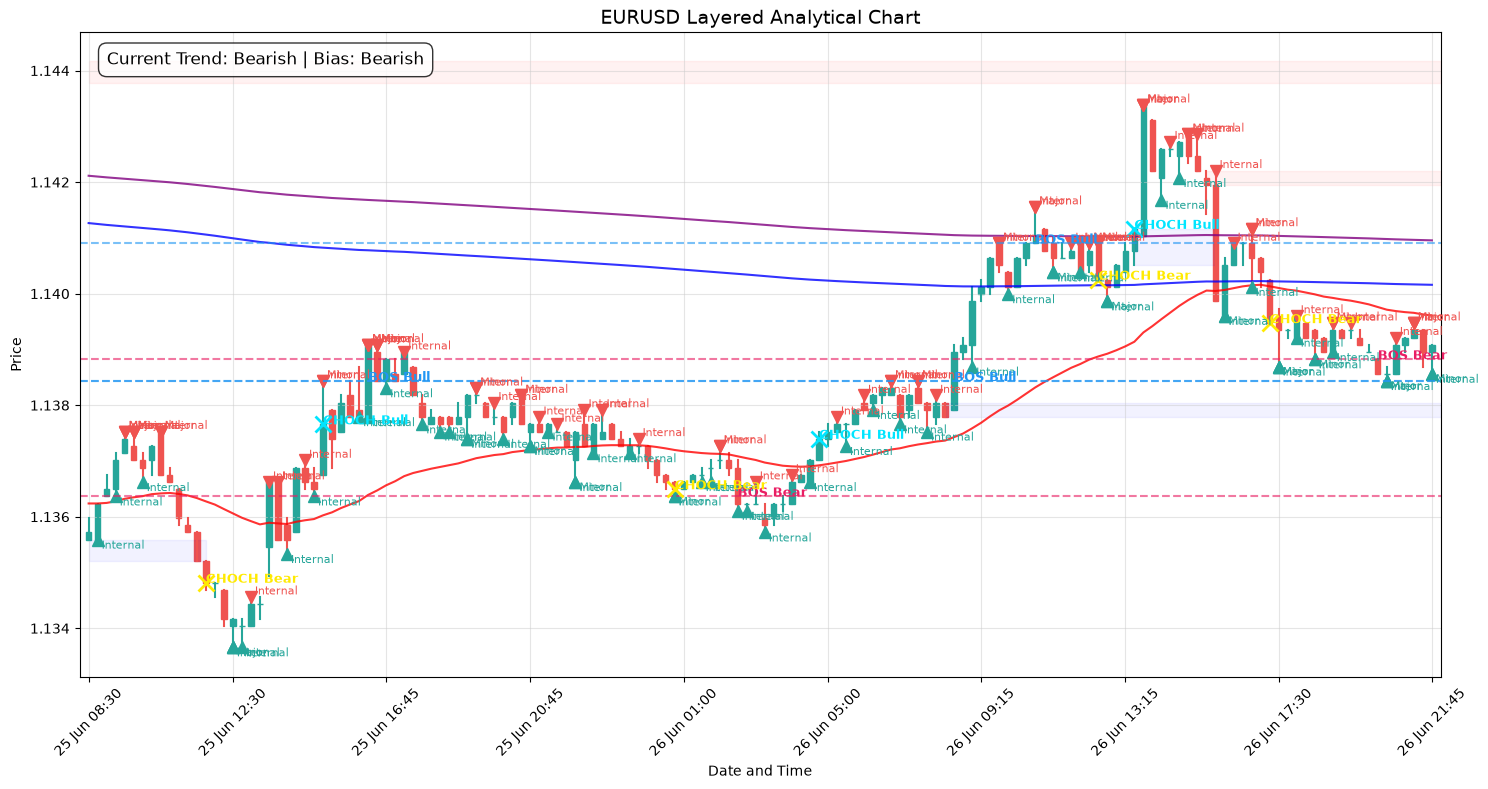

In [7]:
toggles = {
    "Show EMA50": True,
    "Show EMA600": True,
    "Show EMA800": True,
    "Show Swings": True,
    "Show Protected Levels": True,
    "Show BOS": True,
    "Show CHOCH": True,
    "Show Zones": True,
    "Show Trend": True
}

# Render EURUSD layered chart with Date and Time horizontal axis in premium white theme
plot_layered_market_chart("EURUSD", start_idx=400, end_idx=550, layers=toggles)